# ASOS 1-Minute Data Pipeline

Fetch TRUE per-minute precipitation and weather data from ASOS stations via IEM.

**Source:** https://mesonet.agron.iastate.edu/request/asos/1min.phtml

## Key Features
- 1-min `precip` = TRUE precipitation per minute (not hourly running totals)
- Flexible resampling to any interval (5min, 10min, 15min, 1H, etc.)
- Precipitation type classification (rain, snow, freezing rain, etc.)

## Pipeline Steps
1. Fetch raw 1-minute data (monthly chunks)
2. Convert to metric units
3. Resample to desired interval
4. Analyze precipitation types
5. Plot and save results

## 1. Configuration

Configure stations, date range, and output directory.

**Stations:** Use standard 3-letter airport codes (e.g., 'JFK', 'LGA', 'NYC')

**Date Range:** Start and end dates (datetime objects)

**Output Directory:** Where processed CSV files will be saved

In [ ]:
# Setup: Import libraries and configure pipeline
from datetime import datetime
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path to import shared config
sys.path.insert(0, str(Path.cwd().parent))

from config import OUTPUT_DIRS
from asos_fetch import *
import matplotlib.pyplot as plt
import pandas as pd

# CONFIGURATION
STATION_IDS = ['JFK', 'LGA', 'NYC']
START_DATE  = datetime(2024, 1, 1)
END_DATE    = datetime(2024, 1, 30)

# Output directory: Use shared config
OUTPUT_DIR = OUTPUT_DIRS['asos']

print(f'Stations: {STATION_IDS}')
print(f'Period: {START_DATE.date()} to {END_DATE.date()}')
print(f'Output directory: {OUTPUT_DIR.resolve()}')
print('✓ Setup complete')

Stations: ['JFK', 'LGA', 'NYC']
Period: 2024-01-15 to 2024-01-30
Output directory: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/fetched/asos
✓ Setup complete


## 2. Fetch Raw Data

Fetch 1-minute ASOS data from IEM API.

**Note:** Data is fetched in monthly chunks and automatically merged. The `precip` field contains **true per-minute precipitation** (not hourly running totals like the old 5-minute data).

**Data Delay:** ASOS 1-minute data is delayed 18-36 hours (not real-time) due to NCEI collection method.

### 2.0 API Test (Optional - Can Skip)

This cell tests the IEM API to verify it's working correctly. You can skip this cell if you trust the API is functioning.

**Note:** This is a diagnostic cell and not required for the pipeline.

In [2]:
import requests
from io import StringIO
import pandas as pd

url = "https://mesonet.agron.iastate.edu/cgi-bin/request/asos1min.py"

# Test with original working vars
params = {
    'station': 'JFK',
    'tz': 'UTC',
    'year1': START_DATE.year, 'month1': START_DATE.month, 'day1': START_DATE.day,
    'year2': END_DATE.year, 'month2': END_DATE.month, 'day2': END_DATE.day,
    'vars': 'tmpf,dwpf,sknt,drct,precip',
    'sample': '1min',
    'what': 'download',
    'delim': 'comma',
}
response = requests.get(url, params=params, timeout=60)
print(f"Original vars - Status: {response.status_code}, Length: {len(response.text)}")

# Test with new vars
params['vars'] = 'tmpf,dwpf,sknt,drct,gust_sknt,gust_drct,ptype,precip'
response = requests.get(url, params=params, timeout=60)
print(f"New vars - Status: {response.status_code}, Length: {len(response.text)}")
print(f"Response: {response.text[:200]}")

Original vars - Status: 200, Length: 1186332
New vars - Status: 200, Length: 1379964
Response: station,station_name,valid(UTC),tmpf,dwpf,sknt,drct,gust_sknt,gust_drct,ptype,precip
JFK,NEW YORK/JF KENNEDY,2024-01-15 00:00,32,5,20,279,26,276,NP,0.0
JFK,NEW YORK/JF KENNEDY,2024-01-15 00:01,32,5,19


### 2.1 Quick Look at Raw Data

Inspect the raw data structure: columns, shape, and date ranges.

In [3]:
# Cell 2: Fetch data (monthly chunks, merged)
raw_data = fetch_all_stations_1min(STATION_IDS, START_DATE, END_DATE)

FETCHING 1-MINUTE ASOS DATA
Period: 2024-01-15 to 2024-01-30

JFK (JFK Airport):
  2024-01... ✓ 40,240 rows
  ✓ Total: 40,240 rows

LGA (LaGuardia Airport):
  2024-01... ✓ 41,036 rows
  ✓ Total: 41,036 rows

NYC (Central Park):
  2024-01... ✓ 34,333 rows
  ✓ Total: 34,333 rows

✓ Fetched 3/3 stations


In [4]:
# Cell 3: Quick look at raw data
for station_id, df in raw_data.items():
    print(f"\n{station_id}:")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Shape: {df.shape}")
    print(f"  Date range: {df['valid'].min()} to {df['valid'].max()}")


JFK:
  Columns: ['station', 'station_name', 'valid(UTC)', 'tmpf', 'dwpf', 'sknt', 'drct', 'gust_sknt', 'gust_drct', 'ptype', 'precip', 'valid']
  Shape: (40240, 12)
  Date range: 2024-01-01 00:00:00 to 2024-01-29 23:59:00

LGA:
  Columns: ['station', 'station_name', 'valid(UTC)', 'tmpf', 'dwpf', 'sknt', 'drct', 'gust_sknt', 'gust_drct', 'ptype', 'precip', 'valid']
  Shape: (41036, 12)
  Date range: 2024-01-01 00:00:00 to 2024-01-29 23:59:00

NYC:
  Columns: ['station', 'station_name', 'valid(UTC)', 'tmpf', 'dwpf', 'sknt', 'drct', 'gust_sknt', 'gust_drct', 'ptype', 'precip', 'valid']
  Shape: (34333, 12)
  Date range: 2024-01-01 00:00:00 to 2024-01-29 23:59:00


## 3. Convert to Metric Units

Convert all measurements from US units to metric:

- **Temperature:** °F → °C
- **Dewpoint:** °F → °C  
- **Wind Speed/Gusts:** knots → m/s
- **Precipitation:** inches → mm
- **Precipitation Type:** Raw codes mapped to simplified categories (dry, rain, snow, precip, missing)

In [5]:
# Cell 4: Convert to metric
processed_data = process_all_stations(raw_data)


Converting to metric...
  JFK: 40,240 rows, total precip = 147.3 mm
  LGA: 41,036 rows, total precip = 158.2 mm
  NYC: 34,333 rows, total precip = 105.7 mm
✓ Conversion complete



### 3.1 Data Summary

Summary statistics: total precipitation, rainy minutes, average temperature, and average wind speed.

In [6]:
# Cell 5: Check data summary
print("Data Summary:")
print("-" * 50)
for station_id, df in processed_data.items():
    total_precip = df['precip_amount'].sum()
    rainy_mins = (df['precip_amount'] > 0).sum()
    avg_temp = df['temperature'].mean()
    avg_wind = df['wind_speed'].mean()
    # avg_vis = df['visibility_km'].mean()
    print(f"\n{station_id}:")
    print(f"  Precip: {total_precip:.1f} mm ({rainy_mins:,} rainy minutes)")
    print(f"  Temp: {avg_temp:.1f} °C (mean)")
    print(f"  Wind: {avg_wind:.1f} m/s (mean)")
    # print(f"  Visibility: {avg_vis:.1f} km (mean)")

Data Summary:
--------------------------------------------------

JFK:
  Precip: 147.3 mm (512 rainy minutes)
  Temp: 2.3 °C (mean)
  Wind: 5.9 m/s (mean)

LGA:
  Precip: 158.2 mm (502 rainy minutes)
  Temp: 2.9 °C (mean)
  Wind: 5.5 m/s (mean)

NYC:
  Precip: 105.7 mm (391 rainy minutes)
  Temp: 3.1 °C (mean)
  Wind: 3.2 m/s (mean)


### 3.2 Precipitation Type Summary

Count occurrences of each precipitation type (dry, rain, snow, precip, missing) by station.

**Categories:**
- `dry`: No precipitation (NP)
- `rain`: Rain of any intensity (R, R+, R-)
- `snow`: Snow of any intensity (S, S+, S-)
- `precip`: Precipitation detected, type uncertain (P, P?)
- `missing`: Missing data or sensor error (M, ?0-?3)

In [7]:

plot_summary = get_precip_type_summary(processed_data)



Precipitation Type Summary:
--------------------------------------------------
station_id      JFK      LGA      NYC
type                                 
dry         32284.0  33276.0  25665.0
rain         3709.0   4335.0   3633.0
snow         1225.0   1510.0   1258.0
precip       1093.0   1167.0    664.0
missing      1929.0    748.0   3113.0

Percentages:
--------------------------------------------------
station_id   JFK   LGA   NYC
type                        
dry         80.2  81.1  74.8
rain         9.2  10.6  10.6
snow         3.0   3.7   3.7
precip       2.7   2.8   1.9
missing      4.8   1.8   9.1



### 3.3 Preview Processed Data

Preview the first few rows of processed data to see the structure.

In [8]:
processed_data['JFK'].head()

,datetime,station_id,temperature,dewpoint,wind_speed,wind_direction,wind_gust,wind_gust_direction,precip_type,precip_category,precip_amount,precip_rate
0,2024-01-01 00:00:00,JFK,5.555556,-3.333333,3.60108,273.0,4.11552,276.0,NP,dry,0.0,0.0
1,2024-01-01 00:01:00,JFK,5.555556,-3.333333,3.08664,280.0,4.11552,273.0,NP,dry,0.0,0.0
2,2024-01-01 00:02:00,JFK,5.555556,-3.333333,4.11552,274.0,5.14440,272.0,NP,dry,0.0,0.0
3,2024-01-01 00:03:00,JFK,5.555556,-3.333333,4.11552,271.0,5.14440,271.0,NP,dry,0.0,0.0
4,2024-01-01 00:04:00,JFK,5.555556,-3.333333,4.11552,271.0,5.14440,273.0,NP,dry,0.0,0.0


## 3.4 Resample to Custom Interval (Optional)

Resample 1-minute data to a coarser interval (5min, 10min, 15min, 30min, 1H, etc.).

**Note:** Precipitation totals are preserved during resampling (summed, not averaged).

**Common intervals:**
- `'5min'` - 5-minute intervals
- `'15min'` - 15-minute intervals  
- `'1H'` - Hourly intervals

In [9]:
# Cell 3.4: Resample to custom interval
# Options: '5min', '10min', '15min', '30min', '1H'

RESAMPLE_INTERVAL = '5min'

resampled_data = resample_all_stations(processed_data, interval=RESAMPLE_INTERVAL)

# Check totals still match
print(f"\n{RESAMPLE_INTERVAL} totals :")
for station_id, df in resampled_data.items():
    total = df['precip_amount'].sum()
    print(f"  {station_id}: {total:.1f} mm")

Resampling to 5min intervals...
  JFK: 8,352 rows
  LGA: 8,352 rows
  NYC: 8,352 rows
✓ Resampling to 5min complete


5min totals :
  JFK: 147.3 mm
  LGA: 158.2 mm
  NYC: 105.7 mm


## 4. Save Data

Save raw and/or processed data to CSV files.

**Location:** `dataset/raw/fetched/asos/`

**Filenames:**
- Raw: `ALL_STATIONS_raw_YYYY-MM-DD_YYYY-MM-DD.csv` (US units: °F, knots, inches)
- Processed: `ALL_STATIONS_1min_YYYY-MM-DD_YYYY-MM-DD.csv` (metric: °C, m/s, mm)
- Resampled: `ALL_STATIONS_{interval}_YYYY-MM-DD_YYYY-MM-DD.csv`

In [10]:
# Save data: choose type to save
# Types: 'raw' (US units: °F, knots, inches), 'standard' (metric: °C, m/s, mm, 1-min), 'resampled' (aggregated intervals)
all_asos_datasets = {
    'raw'      : raw_data,              # fetched from IEM/NOAA, US units 
    'standard' : processed_data,   # standardized 
    'resampled': resampled_data   # standardized resampled
}

type = 'standard'  # Options: 'raw', 'standard', 'resampled'

_ = save_asos(
    type=type,
    datasets=all_asos_datasets,
    overwrite=True
)


Saving to: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/fetched/asos
----------------------------------------
  ✓ ASOS_standard_2024-01-01_2024-01-29.csv (115,609 rows)
----------------------------------------
✓ Save complete: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/fetched/asos



## 7. Compute Accumulated Precipitation

Calculate cumulative (running total) precipitation from the start date.

Useful for tracking total precipitation over the entire period.

In [11]:
# Cell 8: Compute accumulated precipitation
accumulated = compute_accumulated_all(processed_data, START_DATE, END_DATE)

print("Accumulated totals:")
for station_id, df in accumulated.items():
    if len(df) > 0 and 'accumulated_mm' in df.columns:
        final = df['accumulated_mm'].iloc[-1]
        print(f"  {station_id}: {final:.1f} mm")
    else:
        print(f"  {station_id}: No data in date range")

Accumulated totals:
  JFK: 48.5 mm
  LGA: 59.7 mm
  NYC: 41.9 mm


## 8. Visualization

Plot precipitation and weather data to visualize patterns and compare stations.

**Note:** Ensure data is loaded (either from processing above or loading saved data).

### 8.1 Precipitation by Type

Plot time series showing precipitation colored by type (rain, snow, etc.).

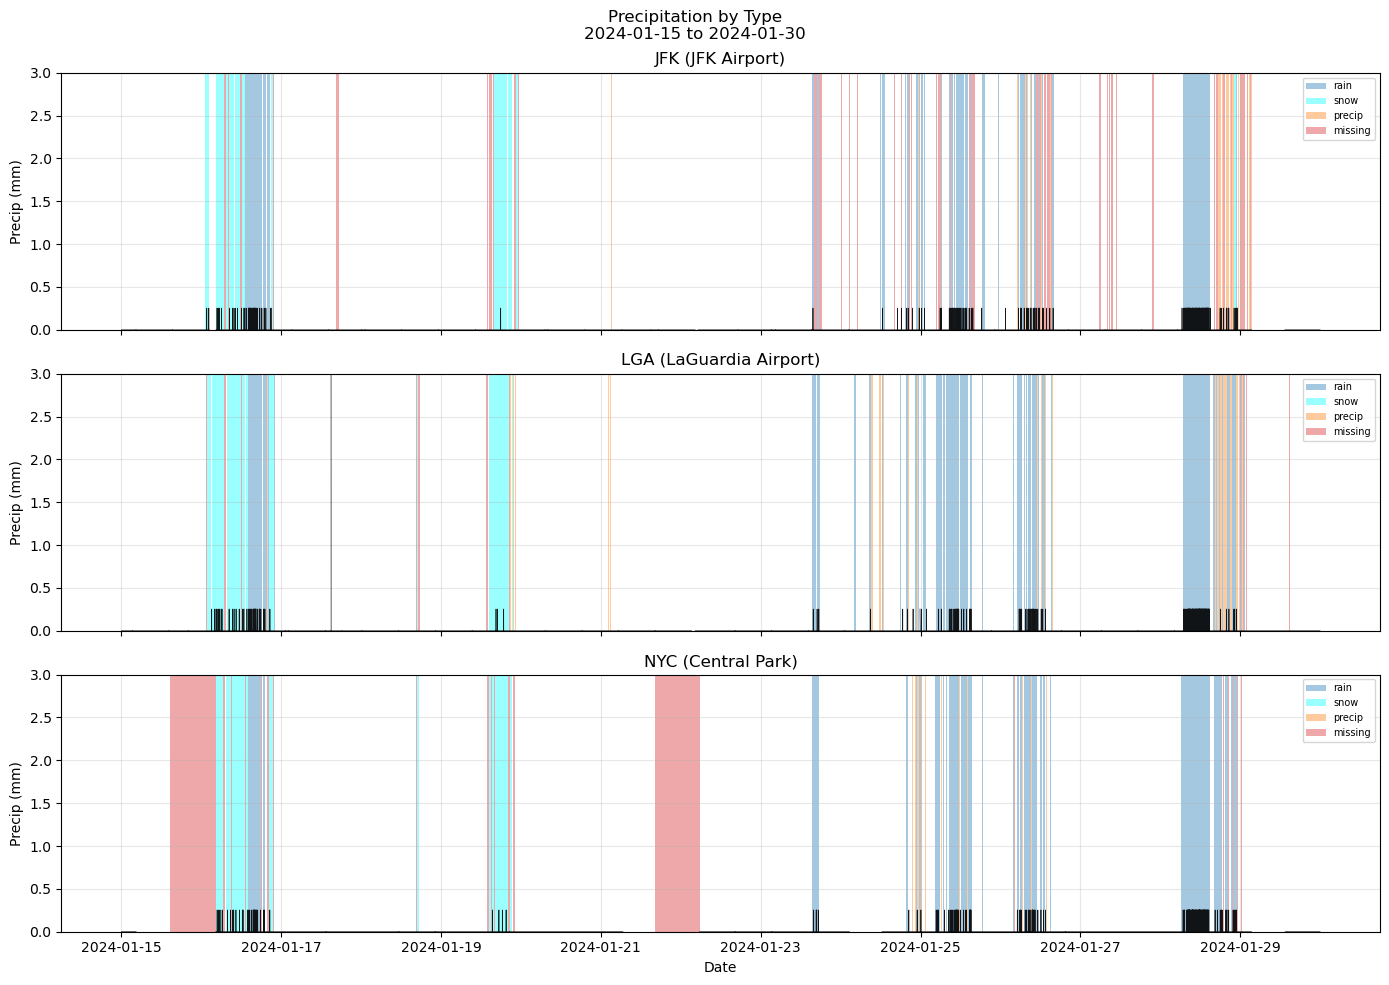

In [12]:
# Cell 10: Plot precipitation by type
fig, axes = plot_precip_by_type(
    processed_data, ylims=[0,3],
    start_date=START_DATE,
    end_date=END_DATE
)
plt.show()

### 8.2 All Weather Parameters

Plot multiple weather parameters (precipitation, temperature, wind speed) in separate subplots.

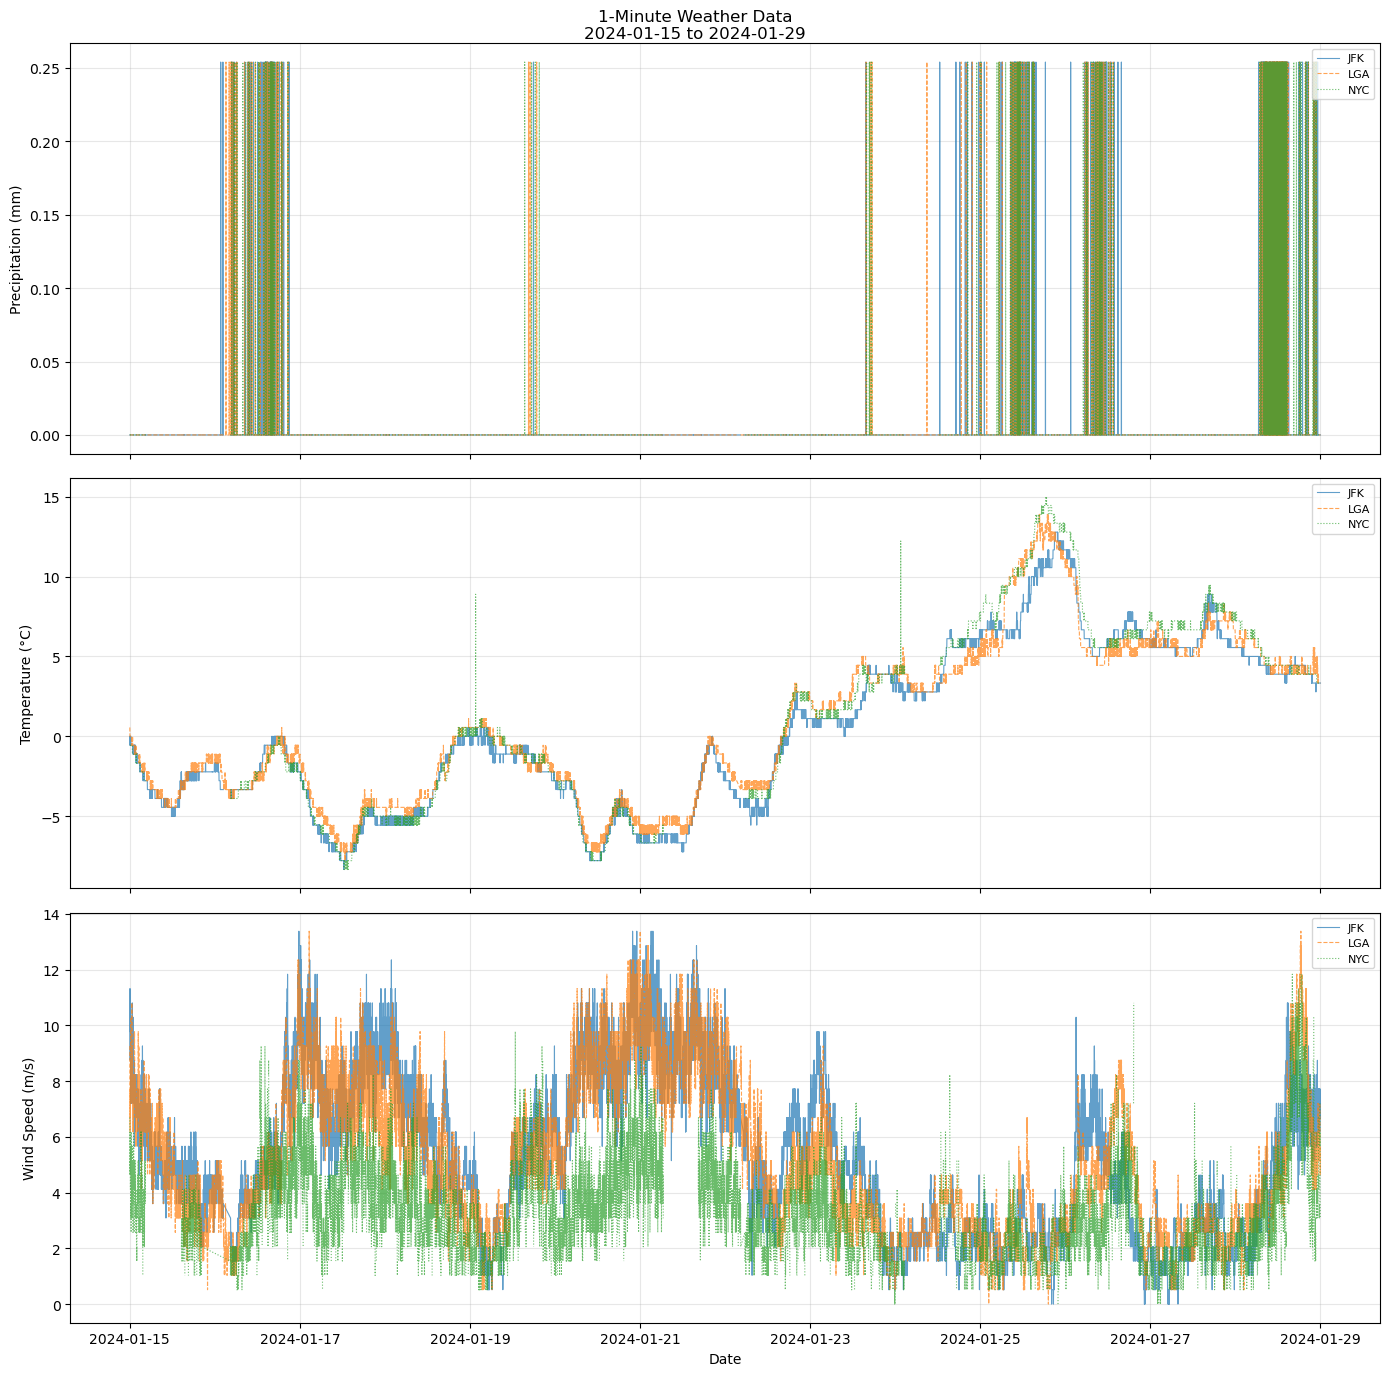

In [13]:
# Cell 11: Plot all weather parameters
fig, axes = plot_weather_subplots(
    processed_data,
    params=['precip_amount', 'temperature', 'wind_speed'],
    start_date=START_DATE,
    end_date='2024-01-29',
    figsize=(14, 14), 
    title_prefix='1-Minute' ,
#    ylims=[0, 3]
)
plt.show()

### 8.3 Accumulated Precipitation

Plot cumulative precipitation (running total) over time.

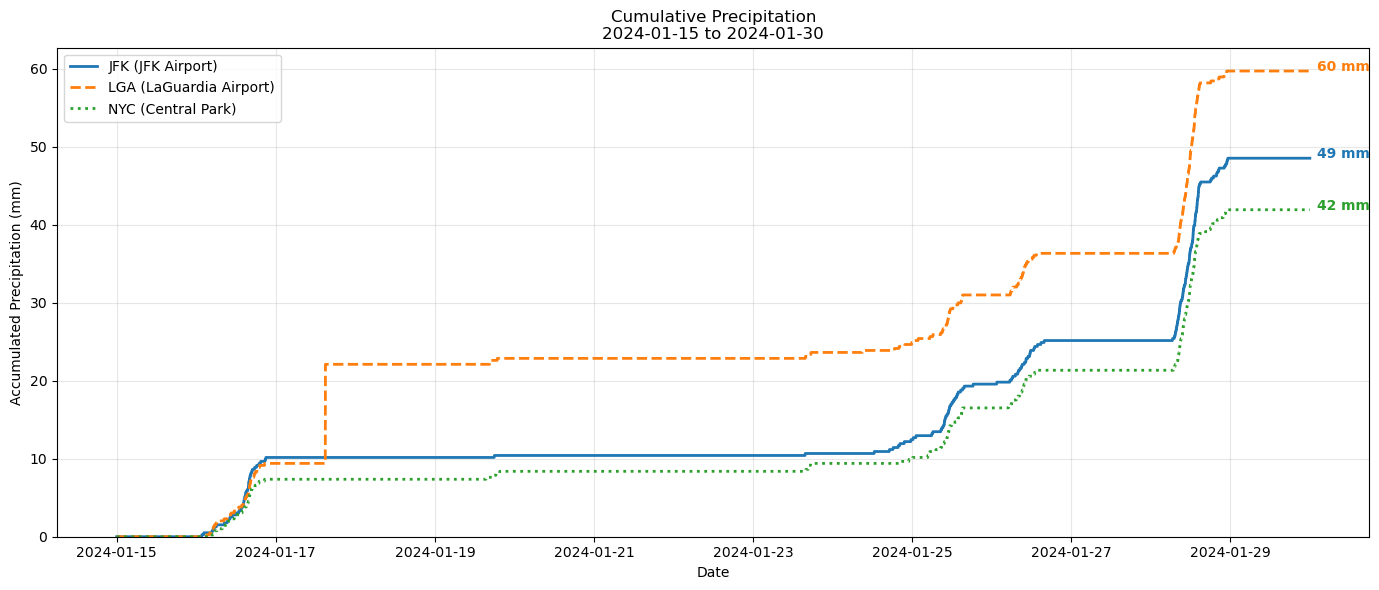

In [14]:
# Cell 12: Plot accumulated precipitation
fig, ax = plot_accumulated(
    accumulated,
    start_date=START_DATE,
    end_date=END_DATE
)
plt.show()

## 9. Summary

Final summary of the pipeline execution: period, stations, resample interval, variables, and precipitation totals.

In [15]:
# Cell 14: Summary
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nPeriod: {START_DATE.date()} to {END_DATE.date()}")
print(f"Stations: {len(processed_data)}")
print(f"Resample interval: {RESAMPLE_INTERVAL}")
print(f"\nVariables: temperature, dewpoint, wind_speed, wind_gust,")
print(f"           wind_direction, precip_type, precip_amount, precip_rate")
print(f"\nPrecipitation totals:")
for station_id, df in processed_data.items():
    total = df['precip_amount'].sum()
    print(f"  {station_id}: {total:.1f} mm")
print(f"\nOutput directory: {OUTPUT_DIR.resolve()}")
print("\n" + "=" * 60)
print("✓ COMPLETE")

SUMMARY

Period: 2024-01-15 to 2024-01-30
Stations: 3
Resample interval: 5min

Variables: temperature, dewpoint, wind_speed, wind_gust,
           wind_direction, precip_type, precip_amount, precip_rate

Precipitation totals:
  JFK: 147.3 mm
  LGA: 158.2 mm
  NYC: 105.7 mm

Output directory: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/fetched/asos

✓ COMPLETE


## 10. Load Data (Optional)

Load previously saved data instead of fetching/processing again.

**Use this section if:**
- You've already run the fetch/preprocess steps
- You want to skip to visualization
- You're working with saved data from a previous run

In [16]:
# USAGE EXAMPLE: Load saved data files
LOAD_DATA = True
LOAD_PREFIX = 'standard'  # 'standard', '1H', '5min', etc., or '' for all

if LOAD_DATA:
    print("=" * 70)
    print("LOADING SAVED DATA")
    print("=" * 70)
    
    all_loaded_data = load_all_data(OUTPUT_DIR, prefix=LOAD_PREFIX, verbose=True)
    
    if all_loaded_data:
        target_key = f"{START_DATE.strftime('%Y-%m-%d')}_{END_DATE.strftime('%Y-%m-%d')}"
        processed_data, selected_key, info = select_longest_dataset(all_loaded_data, target_key)
        
        print(f"\n{info}")
        if selected_key != target_key:
            print(f"  → To use different range: processed_data = all_loaded_data['YYYY-MM-DD_YYYY-MM-DD']")
    else:
        print("\n✗ No data files found - run fetch/preprocess steps first")
else:
    print("ℹ Skipping load (using processed data from above)")


all_loaded_data

LOADING SAVED DATA

Loading 3 file(s) from /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/fetched/asos
----------------------------------------------------------------------
Loading: ASOS_standard_2023-11-01_2023-11-29.csv... ✓ 2 stations, 80,848 total rows
Loading: ASOS_standard_2024-01-01_2024-01-29.csv... ✓ 3 stations, 115,609 total rows
Loading: ASOS_standard_2024-01-01_2024-02-27.csv... ✓ 3 stations, 233,838 total rows
----------------------------------------------------------------------
✓ Loaded 3 file(s)
  2023-11-01_2023-11-29: 2 stations
  2024-01-01_2024-01-29: 3 stations
  2024-01-01_2024-02-27: 3 stations

✓ Using dataset with most rows: 2024-01-01_2024-02-27 (233,838 rows)
  → To use different range: processed_data = all_loaded_data['YYYY-MM-DD_YYYY-MM-DD']


{'2023-11-01_2023-11-29': {'JFK':                  datetime station_id  temperature  dewpoint  wind_speed  \
  0     2023-11-01 00:00:00        JFK     8.888889  1.111111     3.08664   
  1     2023-11-01 00:01:00        JFK     8.888889  1.111111     2.57220   
  2     2023-11-01 00:02:00        JFK     8.888889  1.111111     3.08664   
  3     2023-11-01 00:03:00        JFK     8.888889  1.111111     3.08664   
  4     2023-11-01 00:04:00        JFK     8.888889  1.111111     3.08664   
  ...                   ...        ...          ...       ...         ...   
  39251 2023-11-29 23:55:00        JFK     1.111111 -8.333333     6.68772   
  39252 2023-11-29 23:56:00        JFK     1.111111 -8.333333     6.68772   
  39253 2023-11-29 23:57:00        JFK     1.111111 -8.333333     6.68772   
  39254 2023-11-29 23:58:00        JFK     1.111111 -7.777778     7.20216   
  39255 2023-11-29 23:59:00        JFK     1.111111 -8.333333     6.68772   
  
         wind_direction  wind_gust  wind_